# The Core Intuition of SVD

## 1. Beyond Eigenvalues
Eigenvalues and diagonalization only work for square matrices ($n \times n$). Most real-world data matrices are rectangular ($m \times n$), representing datasets where rows are samples and columns are features. 

**Singular Value Decomposition (SVD)** is the mathematical generalization of diagonalization. It can decompose *any* matrix, regardless of shape or dimensions.

## 2. The Geometric Intuition
While diagonalization looks for non-rotating vectors, SVD maps out how a transformation stretches a multi-dimensional sphere. 
* It takes a hyper-sphere in your input space.
* It transforms it into a hyper-ellipse in the output space.
* The principal axes of this ellipse are the singular vectors, and their lengths are the singular values.


# Mathematical Formulation of SVD

Every real $m \times n$ matrix $A$ can be factored into three distinct matrices:

$$A = U \Sigma V^T$$

Where:
* **$U$ (Left Singular Vectors):** An $m \times m$ orthogonal matrix ($U^T U = I$). The columns of $U$ represent the principal axes of the data in the output space (eigenvectors of $A A^T$).
* **$\Sigma$ (Singular Values):** An $m \times n$ diagonal matrix containing non-negative real numbers sorted in descending order ($\sigma_1 \geq \sigma_2 \geq \dots \geq 0$). These describe the scaling factor along each axis.
* **$V^T$ (Right Singular Vectors):** The transpose of an $n \times n$ orthogonal matrix ($V^T V = I$). The columns of $V$ represent the principal axes of the data in the input space (eigenvectors of $A^T A$).

## Geometric Mapping Sequence
When computing $A \vec{x}$, the operation happens in three clean geometric steps:
1. **$V^T$** rotates the vector into the input basis space.
2. **$\Sigma$** stretches or compresses the vector along the coordinate axes.
3. **$U$** rotates the scaled vector into the final output space.


# Truncated SVD and Image Compression

## 1. Outer Product Expansion
We can rewrite the matrix $A = U \Sigma V^T$ as a sum of individual rank-1 matrices:

$$A = \sigma_1 u_1 v_1^T + \sigma_2 u_2 v_2^T + \dots + \sigma_r u_r v_r^T$$

Each term $\sigma_i u_i v_i^T$ represents an independent layer of structural pattern in the data, scaled by the importance factor $\sigma_i$.

## 2. Low-Rank Approximation (The Eckart-Young-Mirsky Theorem)
Because the singular values $\sigma_i$ drop off drastically in size, the first few terms contain nearly all the matrix's energy and information. 

By keeping only the top $k$ singular values and discarding the rest, we create a truncated approximation matrix $A_k$:

$$A_k \approx \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

## 3. Storage Efficiency & Compression Ratio
A grayscale image matrix of size $m \times n$ requires storing $m \times n$ total pixels. 
A truncated SVD approximation only requires storing:
$$\text{Stored Elements} = k \times (m + n + 1)$$

When $k \ll m, n$, this drops storage costs dramatically. We preserve the macro-structures of the image while discarding high-frequency noise.


In [15]:

#Importing all the libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
from skimage import data,color



--- Loading the Image ---
Width :  512 
Height :  512


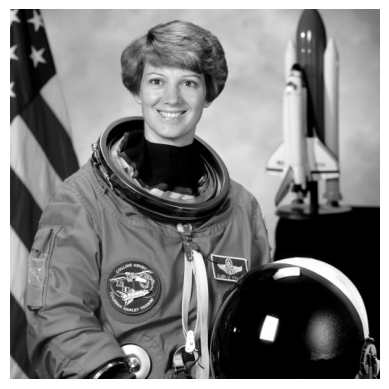

Total Scalar Value required for raw storage :262,144


In [16]:
# ==========================================================
# MODULE 1 : IMPORT THE IMAGE
# ==========================================================

print("--- Loading the Image ---")

#Load the image 
img_color = data.astronaut()

#convert into grayscale
img_gray=color.rgb2gray(img_color)

#Dimension of image Matrix
m,n = img_gray.shape
print("Width : ",m,"\nHeight : ",n)

#plot image
plt.imshow(img_gray, cmap='gray')
plt.axis('off')#off the axis
plt.show()


#
raw_elements=m*n
print(f"Total Scalar Value required for raw storage :{raw_elements:,}")



In [17]:
# ==========================================================
# MODULE 2 : COMPUTING MATRIX FACTORIZATION VIA SVD
# ==========================================================

print("--- Computing the SVD ---")

# full_matrices=False prevents allocation of redundant spatial coordinate zeros
U,s,Vt=la.svd(img_gray,full_matrices=False)
print("Decompostion Completed:")
print(f"Matrix U shape :{U.shape}")
print(f"Matrix Vt shape : {Vt.shape}")
print(f"Singular values (Rank) :{len(s)}")

--- Computing the SVD ---
Decompostion Completed:
Matrix U shape :(512, 512)
Matrix Vt shape : (512, 512)
Singular values (Rank) :512


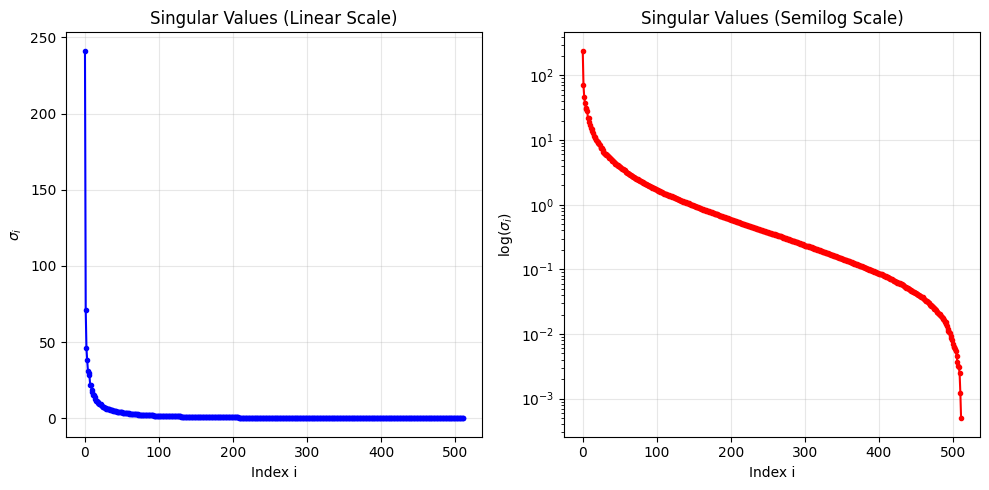

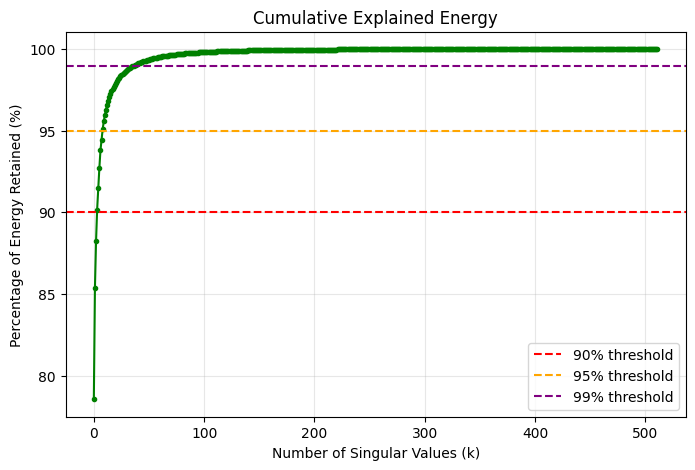

To retain 90% energy, keep first 4 singular values (out of 512).
To retain 95% energy, keep first 9 singular values (out of 512).
To retain 99% energy, keep first 38 singular values (out of 512).


In [18]:
# ==========================================================
# MODULE 2.1: Singular Value Decay Plot
# ==========================================================


# Ploting singular values on a semilog scale
plt.figure(figsize=(10, 5))

# Linear scale plot (left subplot)
plt.subplot(1, 2, 1)
plt.plot(s, 'b-o', markersize=3)
plt.title('Singular Values (Linear Scale)')
plt.xlabel('Index i')
plt.ylabel(r'$\sigma_i$')
plt.grid(True, alpha=0.3)

# Semilog scale plot (right subplot)
plt.subplot(1, 2, 2)
plt.semilogy(s, 'r-o', markersize=3)
plt.title('Singular Values (Semilog Scale)')
plt.xlabel('Index i')
plt.ylabel(r'$\log(\sigma_i)$')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cumulative explained energy
cumulative_energy = np.cumsum(s**2) / np.sum(s**2) * 100

plt.figure(figsize=(8, 5))
plt.plot(cumulative_energy, 'g-o', markersize=3)
plt.title('Cumulative Explained Energy')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Percentage of Energy Retained (%)')
plt.axhline(y=90, color='r', linestyle='--', label='90% threshold')
plt.axhline(y=95, color='orange', linestyle='--', label='95% threshold')
plt.axhline(y=99, color='purple', linestyle='--', label='99% threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Show how many singular values are needed to retain a given percentage
for threshold in [90, 95, 99]:
    k_needed = np.argmax(cumulative_energy >= threshold) + 1
    print(f"To retain {threshold}% energy, keep first {k_needed} singular values (out of {len(s)}).")

## Compression Ratio vs. Image Quality Trade-off

When we apply truncated SVD to an image of size $m \times n$, storing the full image requires $m \times n$ numbers.  
Using rank-$k$ approximation, we store three matrices: $\mathbf{U}_k$ ($m \times k$), $\boldsymbol{\Sigma}_k$ ($k \times k$ diagonal), and $\mathbf{V}_k^T$ ($k \times n$).  
The total storage becomes $mk + k + kn = k(m + n + 1)$.

**Compression ratio** (original / compressed) = $\frac{mn}{k(m+n+1)}$.

- **Low rank ($k$ small)** → high compression, but image loses fine details (blurry/blocky).
- **High rank ($k$ large)** → low compression, but image quality nearly matches original.

**Example:** For a $512 \times 512$ image,  
- $k=5$: compression ratio $\approx 512^2 / (5 \times 1025) \approx 51:1$ (aggressive compression, very blurry).  
- $k=50$: ratio $\approx 262144 / (50 \times 1025) \approx 5:1$ (moderate compression, good quality).  
- $k=200$: ratio $\approx 1.3:1$ (minor compression, near‑original quality).

**Choice depends on use case:** thumbnails can tolerate low $k$; medical/diagnostic images require high $k$.

In [19]:
# ==========================================================
# MODULE 3: TRUNCATED SVD AND COMPRESSION 
# ==========================================================

def compress_imag(U,s,Vt,k):
    """Isolating top K features and reconstrcuting Image Matrix """
    #Trucated SVD
    U_k=U[:,:k]
    s_k=s[:k]
    Vt_k=Vt[:k,:]
    
    #Outer product reassembly
    img_k= U_k @ np.diag(s_k) @ Vt_k 
    img_k=np.clip(img_k,0,1)
    
    #Number of elements after compression
    compressed_elements= k*(m + n + 1)
    
    #data retention percentage
    data_retention_pct= (compressed_elements/raw_elements)*100
    
    return img_k,compressed_elements,data_retention_pct

# Generate snapshots at three distinct structural operational ranks
k_values={'k_low':5,'k_mid':20,'k_high':55}

print(" --- Retention of data at diffrent K values ---")
#empty image list to store compressed images
im=[]
#empty list to store the retention percentage
p=[]
for key,value in k_values.items():
    img, elements, pct   = compress_imag(U, s, Vt,value)
    im.append(img)
    p.append(pct)
    print(f"{key} = {value}, Retains: {pct:.2f}% of data")

#Compressed images array    
comp_img_arr = np.array(im)

#Date retension percentage array 
pct_arr=np.array(p)

#List of trucated values
k_list = list(k_values.values())    





 --- Retention of data at diffrent K values ---
k_low = 5, Retains: 1.96% of data
k_mid = 20, Retains: 7.82% of data
k_high = 55, Retains: 21.51% of data


--- Displaying Visual Quality Resolution Scale ---


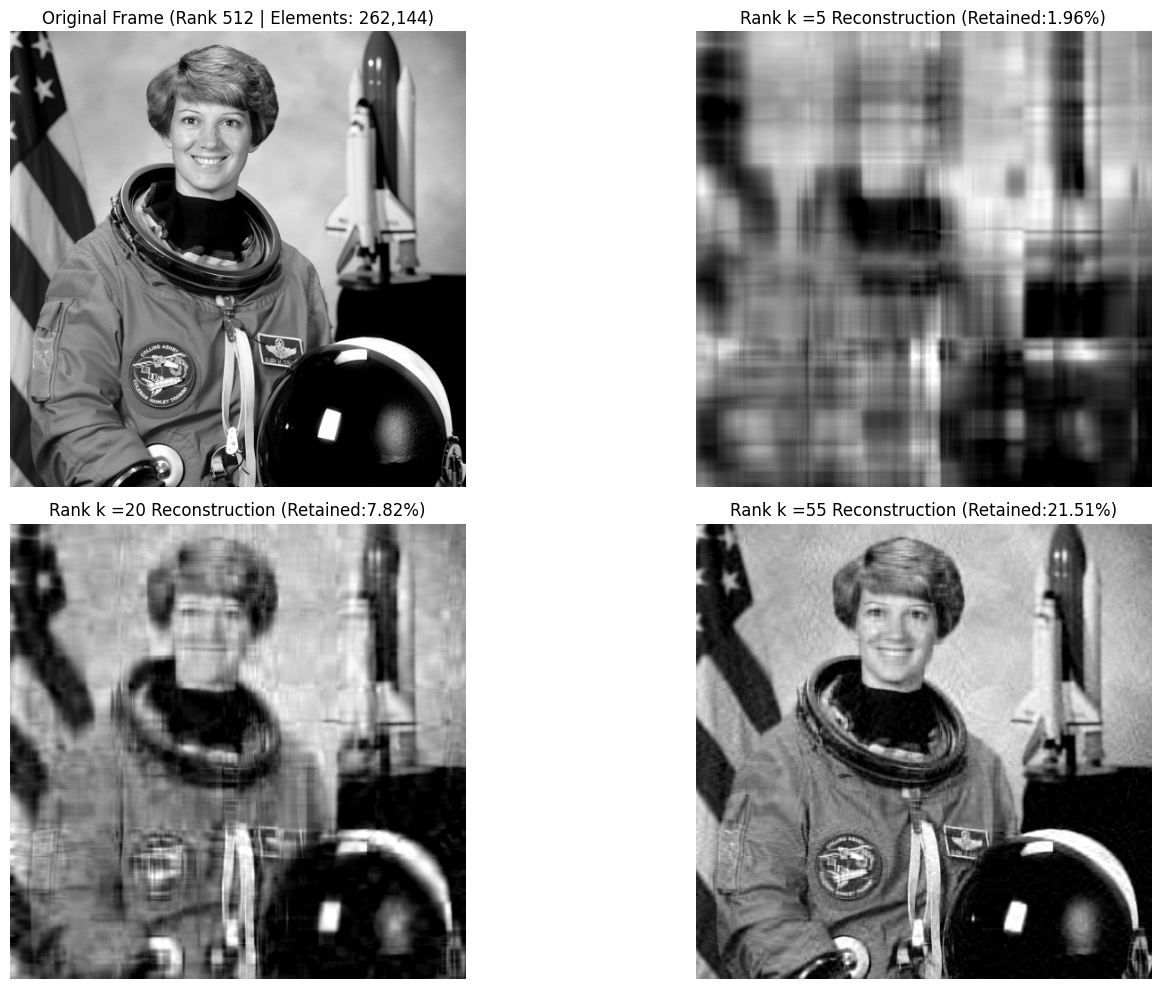

In [20]:
# ==========================================================
# MODULE 4: RENDERING  GRAPHIC  CANVAS
# ==========================================================

print("--- Displaying Visual Quality Resolution Scale ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ind=0
for i in range(2):
    for j in range(2):
        
        if i==0 and j==0:
            axes[i, j].imshow(img_gray, cmap='gray')
            axes[i, j].set_title(f"Original Frame (Rank {len(s)} | Elements: {raw_elements:,})")
            axes[i,j].axis('off')
            continue
        
        axes[i, j].imshow(comp_img_arr [ind], cmap='gray')
        axes[i, j].set_title(f"Rank k ={k_list[ind]} Reconstruction (Retained:{pct_arr[ind]:.2f}%)")
        axes[i,j].axis('off')
        ind+=1 
       
          
            
plt.tight_layout()
plt.show()          
            